In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.models import Model


In [2]:
def load_images(folder):

    images = []

    for digit in os.listdir(folder):

        digit_folder = os.path.join(folder, digit)

        for image_name in os.listdir(digit_folder):

            image_path = os.path.join(
                digit_folder,
                image_name
            )

            img = cv2.imread(
                image_path,
                cv2.IMREAD_GRAYSCALE
            )

            img = img / 255.0

            images.append(img)

    return np.array(images)

In [3]:
train_path = "mnist_png/training"
test_path = "mnist_png/testing"

x_train = load_images(train_path)
x_test = load_images(test_path)

print(x_train.shape)
print(x_test.shape)

(24604, 28, 28)
(10000, 28, 28)


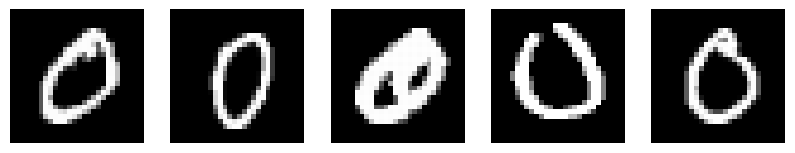

In [4]:
plt.figure(figsize=(10,3))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        x_train[i],
        cmap="gray"
    )

    plt.axis("off")

plt.show()

In [5]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

In [6]:
x_train_noisy = np.clip(
    x_train_noisy,
    0.,
    1.
)

x_test_noisy = np.clip(
    x_test_noisy,
    0.,
    1.
)

In [7]:
x_train_noisy

array([[[0.        , 0.17976274, 0.37289797, ..., 0.39442922,
         0.        , 0.3983892 ],
        [0.        , 0.        , 0.30814835, ..., 0.        ,
         0.        , 0.20533411],
        [0.19174983, 0.0763803 , 0.        , ..., 0.17876346,
         0.        , 0.56383143],
        ...,
        [0.37687514, 0.06023517, 0.36875953, ..., 1.        ,
         0.        , 0.        ],
        [0.08140983, 0.        , 0.        , ..., 0.09145569,
         0.25314371, 0.18867715],
        [0.        , 0.45451285, 0.        , ..., 0.98941387,
         0.        , 0.        ]],

       [[0.42619054, 0.18440538, 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.51938942, 0.        , ..., 0.46228193,
         0.54674639, 0.81570622],
        [0.        , 0.        , 0.46874287, ..., 0.20600114,
         0.4859    , 0.39924647],
        ...,
        [0.        , 0.        , 0.78633583, ..., 0.34829657,
         0.        , 0.94710751],
        [0. 

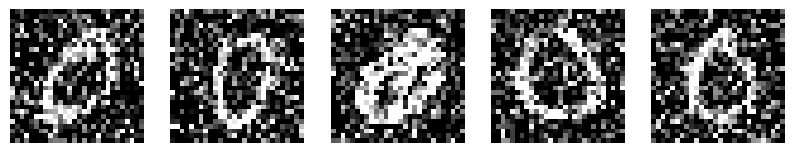

In [8]:
plt.figure(figsize=(10,3))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        x_train_noisy[i],
        cmap="gray"
    )

    plt.axis("off")

plt.show()

In [9]:
x_train = x_train.reshape(
    -1,
    28,
    28,
    1
)

x_test = x_test.reshape(
    -1,
    28,
    28,
    1
)

x_train_noisy = x_train_noisy.reshape(
    -1,
    28,
    28,
    1
)

x_test_noisy = x_test_noisy.reshape(
    -1,
    28,
    28,
    1
)

In [10]:
x_test_noisy

array([[[[6.20681855e-02],
         [2.10490299e-01],
         [0.00000000e+00],
         ...,
         [3.31208617e-01],
         [3.77265059e-02],
         [0.00000000e+00]],

        [[0.00000000e+00],
         [3.47726266e-02],
         [0.00000000e+00],
         ...,
         [5.19086158e-02],
         [0.00000000e+00],
         [0.00000000e+00]],

        [[0.00000000e+00],
         [0.00000000e+00],
         [0.00000000e+00],
         ...,
         [7.00110130e-01],
         [2.55665583e-01],
         [0.00000000e+00]],

        ...,

        [[4.56349713e-01],
         [4.97869196e-01],
         [0.00000000e+00],
         ...,
         [3.20199519e-01],
         [2.60240873e-02],
         [0.00000000e+00]],

        [[8.20892842e-01],
         [0.00000000e+00],
         [0.00000000e+00],
         ...,
         [0.00000000e+00],
         [7.44759539e-01],
         [3.92506436e-01]],

        [[0.00000000e+00],
         [0.00000000e+00],
         [0.00000000e+00],
         ...,
 

In [11]:
input_img = Input(
    shape=(28,28,1)
)

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Conv2D(
    16,
    (3,3),
    activation='relu',
    padding='same'
)(x)

encoded = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

In [12]:
x = Conv2D(
    16,
    (3,3),
    activation='relu',
    padding='same'
)(encoded)

x = UpSampling2D(
    (2,2)
)(x)

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = UpSampling2D(
    (2,2)
)(x)

decoded = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

In [13]:
x

<KerasTensor shape=(None, 28, 28, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_8>

In [14]:
autoencoder = Model(
    input_img,
    decoded
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
autoencoder.compile( optimizer='adam', loss='binary_crossentropy' )

In [16]:
history = autoencoder.fit(

    x_train_noisy,

    x_train,

    epochs=10,

    batch_size=128,

    shuffle=True,

    validation_data=(
        x_test_noisy,
        x_test
    )

)

Epoch 1/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 0.2565 - val_loss: 0.1497
Epoch 2/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.1283 - val_loss: 0.1332
Epoch 3/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.1178 - val_loss: 0.1253
Epoch 4/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.1125 - val_loss: 0.1219
Epoch 5/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.1097 - val_loss: 0.1184
Epoch 6/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.1078 - val_loss: 0.1157
Epoch 7/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.1064 - val_loss: 0.1142
Epoch 8/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.1050 - val_loss: 0.1129
Epoch 9/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.1041 - val_loss: 0.1119
Epoch 10/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.1034 - val_loss: 0.1109


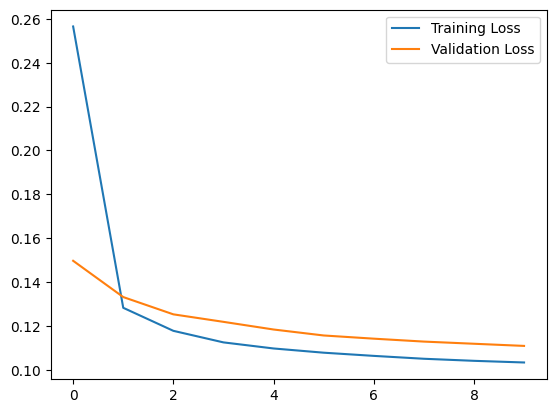

In [17]:
plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()

plt.show()

In [18]:
decoded_imgs = autoencoder.predict(
    x_test_noisy
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


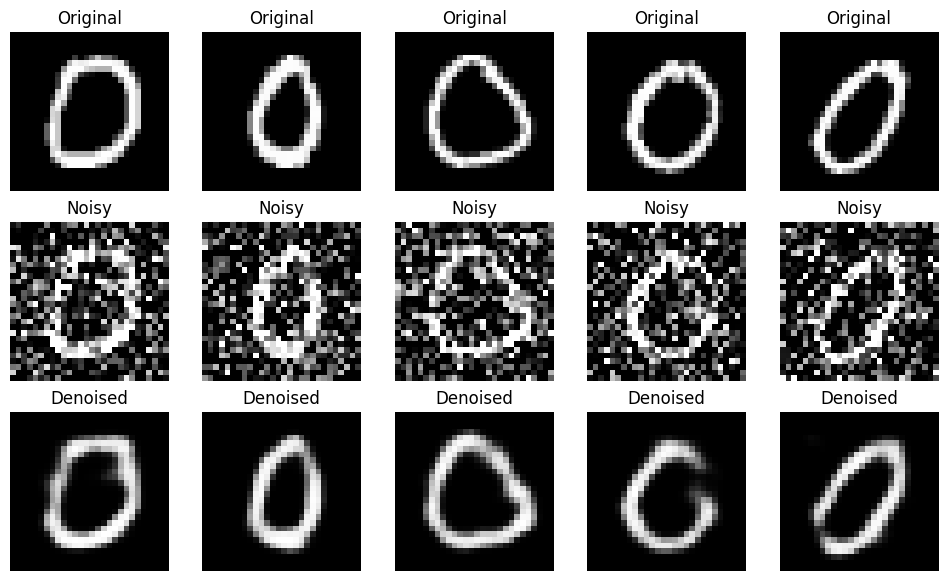

In [19]:
n = 5

plt.figure(
    figsize=(12,7)
)

for i in range(n):

    plt.subplot(
        3,
        n,
        i+1
    )

    plt.imshow(
        x_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title("Original")

    plt.axis('off')

    plt.subplot(
        3,
        n,
        i+n+1
    )

    plt.imshow(
        x_test_noisy[i].reshape(28,28),
        cmap='gray'
    )

    plt.title("Noisy")

    plt.axis('off')

    plt.subplot(
        3,
        n,
        i+2*n+1
    )

    plt.imshow(
        decoded_imgs[i].reshape(28,28),
        cmap='gray'
    )

    plt.title("Denoised")

    plt.axis('off')

plt.show()

In [20]:
autoencoder.save(
    "mnist_denoising_autoencoder.h5"
)